In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [11]:
GLOBAL_CRS = 'EPSG:3435'

In [12]:
gdf = gpd.read_file('data/housing_by_tract.geojson').to_crs(GLOBAL_CRS)
border = gpd.read_file('data/City_Boundary_20250427.geojson').to_crs(GLOBAL_CRS)

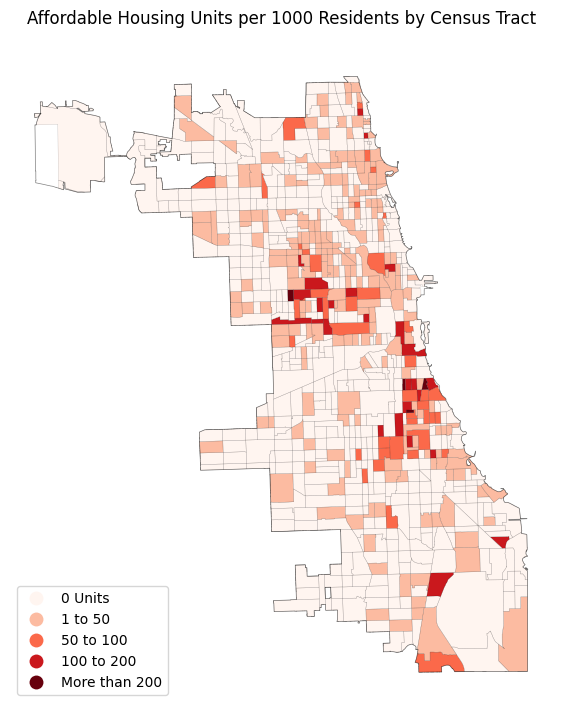

In [13]:
gdf.affordable_units_per_1000 = gdf.affordable_units_per_1000.fillna(0)

ax = gdf.plot(
    'affordable_units_per_1000',
    figsize=(7,10),
    cmap='Reds',
    scheme='userdefined',
    classification_kwds={'bins': [0, 50, 100, 200]},
    legend=True,
    legend_kwds={'loc': 3, 'labels': ['0 Units', '1 to 50', '50 to 100', '100 to 200', 'More than 200']},
)

gdf.boundary.plot(ax=ax, lw=0.25, color='black', alpha=.25)

border.boundary.plot(ax=ax, lw=0.5, color='black', alpha=.5)


ax.set_title('Affordable Housing Units per 1000 Residents by Census Tract')
ax.set_axis_off()

plt.savefig('figures/housing_choropleth_map.png')

In [14]:
gdf['home_value_quartile'] = pd.qcut(gdf.median_home_value, q=4, labels=False) + 1
gdf['rent_quartile'] = pd.qcut(gdf.median_rent, q=4, labels=False) + 1
gdf['median_income_quartile'] = pd.qcut(gdf.median_income, q=4, labels=False) + 1
gdf['share_white_quartile'] = pd.qcut(gdf.share_white, q=4, labels=False) + 1

In [17]:
gdf['rent_categories'] = np.where(
    gdf.median_rent > 2000, 
    'Greater than\n$2000', 
    np.where(
        gdf.median_rent >= 1000,
        'Between $1000\nand $2000',
        'Less than\n$1000'
    )
)

gdf['income_categories'] = np.where(
    gdf.median_income > 100000, 
    'Greater than\n$100,000', 
    np.where(
        gdf.median_income >= 50000,
        'Between $50,000\nand $100,000',
        'Less than\n$50,000'
    )
)

gdf['white_categories'] = np.where(
    gdf.share_white > .5, 
    'Greater than\n 50% white', 
    np.where(
        gdf.share_white >= .1,
        'Between 10%\nand 50% white',
        'Less than\n10% white'
    )
)

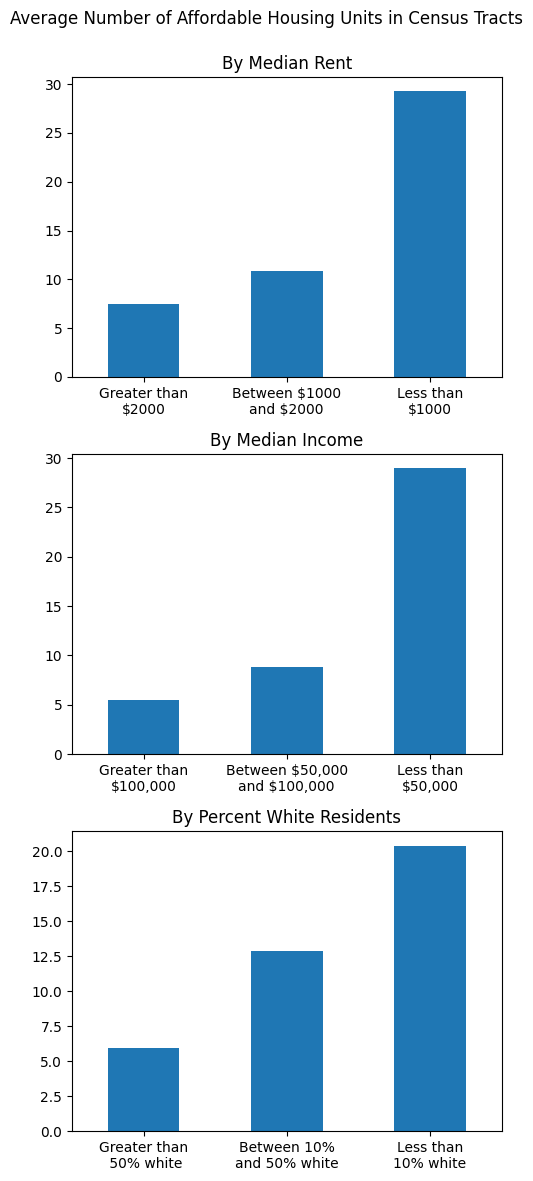

In [18]:
fig, axes = plt.subplots(3, figsize=(5,12), layout='tight')

axes = axes.flatten()
cols = ['rent_categories', 'income_categories', 'white_categories']
titles = ['By Median Rent', 'By Median Income', 'By Percent White Residents']

for col, title, ax in zip(cols, titles, axes):

  gdf.groupby(
    col
  ).affordable_units_per_1000.mean().sort_values().plot(
      ax=ax,
      kind='bar',
      legend=False,
      title=title,
      xlabel='',
    )
  
  ax.tick_params(axis='x', labelrotation=0)


fig.suptitle('Average Number of Affordable Housing Units in Census Tracts\n')
plt.savefig('figures/housing_bar_charts.png')